In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.stats import weibull_min

# ── Johannessen's fitted parameters (Northern North Sea 1973-1999 over 26 years) ──

# Wind speed marginal Weibull
# Note: Johannessen uses scale=alpha, shape=beta (opposite to some conventions)
alpha_W_J = 8.426   # scale parameter
beta_W_J  = 1.708   # shape parameter

def F_W_johannessen(w):
    """Weibull CDF for wind speed - Johannessen eq (4)"""
    return 1 - np.exp(-(w / alpha_W_J)**beta_W_J)

def F_W_inv_johannessen(p):
    """Inverse Weibull CDF"""
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return alpha_W_J * (-np.log(1 - p))**(1 / beta_W_J)

# Conditional Weibull parameters for Hs given W - Johannessen eq (5)
def alpha_Hs_J(w):
    return 1.8 + 0.100 * w**1.322

def beta_Hs_J(w):
    return 2.0 + 0.135 * w

def F_Hs_given_W_J(h, w):
    """Conditional Weibull CDF for Hs given W"""
    alpha = alpha_Hs_J(w)
    beta  = beta_Hs_J(w)
    return 1 - np.exp(-(h / alpha)**beta)

def F_Hs_given_W_inv_J(p, w):
    """Inverse conditional Weibull CDF"""
    p     = np.clip(p, 1e-10, 1 - 1e-10)
    alpha = alpha_Hs_J(w)
    beta  = beta_Hs_J(w)
    return alpha * (-np.log(1 - p))**(1 / beta)

In [19]:
def mu_Tp_J(hs, uw):
    """Conditional mean of Tp given Hs and W - Johannessen eq (8)"""
    term1 = 4.883 + 2.68 * hs**0.529
    term2 = 1 - 0.19 * (uw - (1.764 + 3.426 * hs**0.78)) / \
                       (1.764 + 3.426 * hs**0.78)
    return term1 * term2

def sigma_Tp_J(hs, uw):
    """Conditional std dev of Tp given Hs and W - Johannessen eq (8)"""
    mu = mu_Tp_J(hs, uw)
    return (-1.7e-3 + 0.259 * np.exp(-0.113 * hs)) * mu

def get_lognormal_params_J(hs, uw):
    """Convert mean and std of Tp to lognormal parameters - eq (7)"""
    mu_tp    = mu_Tp_J(hs, uw)
    sigma_tp = sigma_Tp_J(hs, uw)
    vTp      = sigma_tp / mu_tp
    
    mu_ln    = np.log(mu_tp / np.sqrt(1 + vTp**2))
    sigma_ln = np.sqrt(np.log(1 + vTp**2))
    return mu_ln, sigma_ln

def F_Tp_given_Hs_W_J(t, hs, uw):
    """Conditional lognormal CDF for Tp given Hs and W"""
    mu_ln, sigma_ln = get_lognormal_params_J(hs, uw)
    return norm.cdf((np.log(t) - mu_ln) / sigma_ln)

def F_Tp_given_Hs_W_inv_J(p, hs, uw):
    """Inverse conditional lognormal CDF"""
    p = np.clip(p, 1e-10, 1 - 1e-10)
    mu_ln, sigma_ln = get_lognormal_params_J(hs, uw)
    return np.exp(mu_ln + sigma_ln * norm.ppf(p))

In [20]:
def U1_to_W_J(u1):
    p = np.clip(norm.cdf(u1), 1e-10, 1 - 1e-10)
    return F_W_inv_johannessen(p)

def U2_to_Hs_J(u2, w):
    p = np.clip(norm.cdf(u2), 1e-10, 1 - 1e-10)
    return F_Hs_given_W_inv_J(p, w)

def U3_to_Tp_J(u3, h, w):
    p = np.clip(norm.cdf(u3), 1e-10, 1 - 1e-10)
    return F_Tp_given_Hs_W_inv_J(p, h, w)

In [21]:
K1Y           = 8760      # hourly observations — Chai et al. convention
return_period = 100
p_exceedance  = 1 / (return_period * K1Y)
beta_target   = norm.ppf(1 - p_exceedance)

print(f"Beta target: {beta_target:.4f}")   # expect ~4.75

n_theta = 50
n_phi   = 100
theta_vals = np.linspace(0.01, np.pi - 0.01, n_theta)
phi_vals   = np.linspace(0, 2 * np.pi, n_phi)

W_contour_J  = np.full((n_theta, n_phi), np.nan)
Hs_contour_J = np.full((n_theta, n_phi), np.nan)
Tp_contour_J = np.full((n_theta, n_phi), np.nan)

for i, theta in enumerate(theta_vals):
    for j, phi in enumerate(phi_vals):
        u1 = beta_target * np.cos(theta)
        u2 = beta_target * np.sin(theta) * np.cos(phi)
        u3 = beta_target * np.sin(theta) * np.sin(phi)
        
        try:
            w = U1_to_W_J(u1)
            h = U2_to_Hs_J(u2, w)
            t = U3_to_Tp_J(u3, h, w)
            
            # Physical filters
            if w < 0 or w > 50:   continue
            if h < 0 or h > 30:   continue
            if t < 1 or t > 30:   continue
            
            W_contour_J[i, j]  = w
            Hs_contour_J[i, j] = h
            Tp_contour_J[i, j] = t
            
        except Exception:
            pass

print(f"Max W (10m, 1-h):  {np.nanmax(W_contour_J):.1f} m/s")
print(f"Max W (hub, 10min): {np.nanmax(W_contour_J) * 1.10 * (150/10)**0.11:.2f} m/s  (expect ~57.64)")
print(f"Max Hs: {np.nanmax(Hs_contour_J):.1f} m")
print(f"Max Tp: {np.nanmax(Tp_contour_J):.1f} s")

Beta target: 4.7266
Max W (10m, 1-h):  39.0 m/s
Max W (hub, 10min): 57.75 m/s  (expect ~57.64)
Max Hs: 15.8 m
Max Tp: 24.5 s


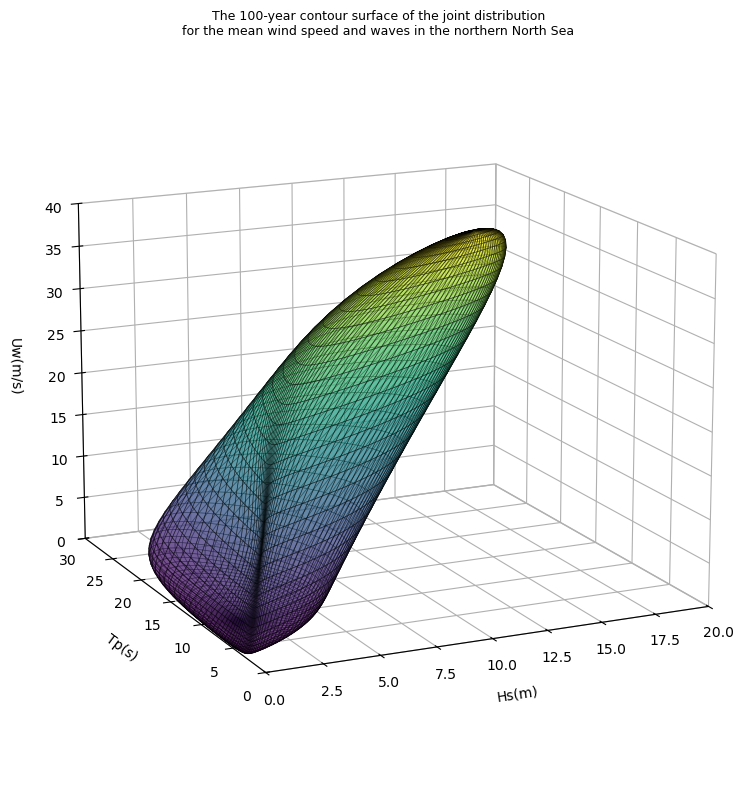

In [61]:
W_plot  = np.ma.masked_invalid(W_contour_J)
Hs_plot = np.ma.masked_invalid(Hs_contour_J)
Tp_plot = np.ma.masked_invalid(Tp_contour_J)

fig = plt.figure(figsize=(9, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.plot_surface(Hs_plot, Tp_plot, W_plot,
                cmap='viridis',   # ✅ changed
                alpha=0.5,
                linewidth=0.5,
                edgecolor='k',
                rstride=1,
                cstride=1,
                clip_on=True)

# Labels
ax.set_xlabel('Hs(m)',   labelpad=10)
ax.set_ylabel('Tp(s)',   labelpad=10)
ax.set_zlabel('Uw(m/s)', labelpad=10)

# Limits
ax.set_xlim(0, 20)
ax.set_ylim(0, 30)
ax.set_zlim(0, 40)

# ✅ Flip Hs axis so Z-axis appears on LEFT
ax.invert_xaxis()

# Optional: ensure Tp grows "away" from Hs nicely
ax.invert_yaxis()

# Clean panes
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('lightgrey')

# ✅ View angle tuned to match your description
ax.view_init(elev=15, azim=65)

# Title
ax.set_title('The 100-year contour surface of the joint distribution\n'
             'for the mean wind speed and waves in the northern North Sea',
             fontsize=9)

plt.tight_layout()
plt.savefig('johannessen_3D_matched.png', dpi=150, bbox_inches='tight')
plt.show()

V_hub=6.98 m/s -> U_w=4.71 m/s: 500 points
V_hub=10.59 m/s -> U_w=7.15 m/s: 500 points
V_hub=25 m/s -> U_w=16.87 m/s: 500 points
V_hub=57.64 m/s -> U_w=38.90 m/s: 500 points


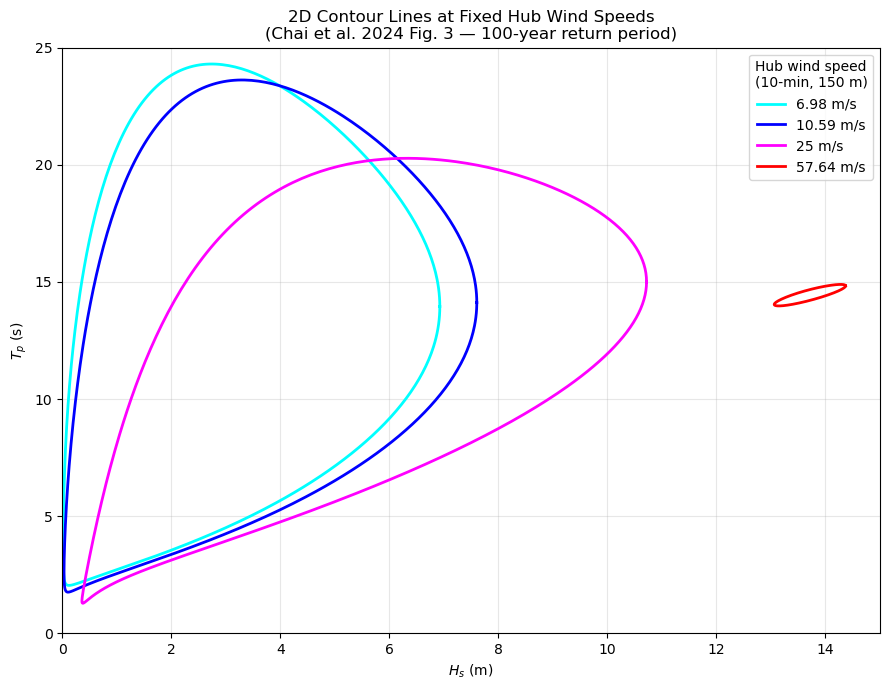

In [24]:
fig, ax = plt.subplots(figsize=(9, 7))

# Hub wind speeds from Chai et al. Fig. 3 (10-min, 150 m hub)
hub_speeds = [6.98, 10.59, 25, 57.64]
colors     = ['cyan', 'blue', 'magenta', 'red']

# Conversion: V_hub (10-min, 150m) -> U_w (1-h, 10m)
# Eq. 9: U_hub = U_w * (150/10)^0.11, then V_hub = U_hub * 1.10
def hub_to_10m(V_hub, a=0.11, H_hub=150, H_ref=10, factor=1.10):
    return V_hub / (factor * (H_hub / H_ref)**a)

for V_hub, colour in zip(hub_speeds, colors):
    
    w_target = hub_to_10m(V_hub)   # convert to 10m 1-h speed
    
    p_w      = np.clip(F_W_johannessen(w_target), 1e-10, 1 - 1e-10)
    u1_fixed = norm.ppf(p_w)
    
    if abs(u1_fixed) >= beta_target:
        print(f"V_hub={V_hub} m/s (U_w={w_target:.2f} m/s) not on contour sphere, skipping")
        continue
    
    theta_fixed = np.arccos(u1_fixed / beta_target)
    phi_sweep   = np.linspace(0, 2 * np.pi, 500)
    
    Hs_curve, Tp_curve = [], []
    
    for phi in phi_sweep:
        u2 = beta_target * np.sin(theta_fixed) * np.cos(phi)
        u3 = beta_target * np.sin(theta_fixed) * np.sin(phi)
        
        try:
            h = F_Hs_given_W_inv_J(np.clip(norm.cdf(u2), 1e-10, 1-1e-10), w_target)
            t = F_Tp_given_Hs_W_inv_J(np.clip(norm.cdf(u3), 1e-10, 1-1e-10), h, w_target)
            
            if 0 < h < 25 and 1 < t < 30:
                Hs_curve.append(h)
                Tp_curve.append(t)
        except Exception:
            pass
    
    if len(Hs_curve) > 10:
        ax.plot(Hs_curve, Tp_curve, color=colour,
                linewidth=2, label=f'{V_hub} m/s')
        print(f"V_hub={V_hub} m/s -> U_w={w_target:.2f} m/s: {len(Hs_curve)} points")

ax.set_xlabel('$H_s$ (m)')
ax.set_ylabel('$T_p$ (s)')
ax.set_title('2D Contour Lines at Fixed Hub Wind Speeds\n'
             '(Chai et al. 2024 Fig. 3 — 100-year return period)')
ax.legend(title='Hub wind speed\n(10-min, 150 m)')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 15)
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('johannessen_2D_fixed.png', dpi=150)
plt.show()